In [1]:
import nbimporter
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from torch import nn
from torch.optim import SGD
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from os.path import join
import torch
import numpy as np
from PIL import Image
from os import path

import python_file.dataclass as StreetSign
import python_file.function as Function
import python_file.network as Network

import matplotlib.pyplot as plt

from python_file.dirPath import csvDir, imageDir, dayTest, historiesDir

np.random.seed(1328)
torch.random.manual_seed(1328)

#number of epoch
epoche = 5

In [2]:
#resize normale
tran = transforms.Compose([StreetSign.Rescale(32),StreetSign.RandomCrop(32),StreetSign.ToTensor()])

In [3]:
datatrain = StreetSign.StreetSignDataset(csvDir / 'classes.csv',imageDir,tran)
datatest = StreetSign.StreetSignTest( dayTest / 'prova.txt',dayTest,tran)

In [4]:
datatrain_loader = DataLoader(datatrain, batch_size=1024, shuffle=True)
datatest_loader = DataLoader(datatest, batch_size=1024, shuffle=True)

In [5]:
minialexnetV2_datatrain = Network.MiniAlexNetV2()

minialexnetV2_datatrain = Function.train_classifier(minialexnetV2_datatrain, datatrain_loader, datatest_loader, \
                                                    'minialexnetV2_dataset', epochs = epoche, save_model=False)

minialexnetV2_data_test_probabilities, data_labels_test = Function.test_classifier(minialexnetV2_datatrain,
                                                                                   datatest_loader)

data_labels_test

array([0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1,
       1, 2, 1, 0, 2, 1, 1, 1, 1, 0, 2, 1, 2, 2, 1, 2, 1, 0, 2, 1, 1, 0,
       1, 1, 2, 2, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 2, 0, 1, 2, 1,
       1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 0, 2, 0, 2, 1, 1, 2, 2, 1, 0, 1, 1,
       1, 2, 1, 2, 2, 1, 1, 1, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 2, 1, 1, 1, 0, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       2, 0, 0, 1, 1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 0, 1, 0, 2, 1, 0, 1, 1,
       2, 1, 1, 2, 1, 2, 1, 1, 1, 0, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 1, 1, 1, 0,
       1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 0, 2, 2, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 0, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 2, 0,

In [6]:
print(f"Shape probabilità: {minialexnetV2_data_test_probabilities.shape}")
print(f"Classi uniche nelle etichette: {np.unique(data_labels_test)}")

Shape probabilità: (330, 4)
Classi uniche nelle etichette: [0 1 2]


Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.591
  Classe 1: 0.674
  Classe 2: 0.740

AUC macro (media): 0.668


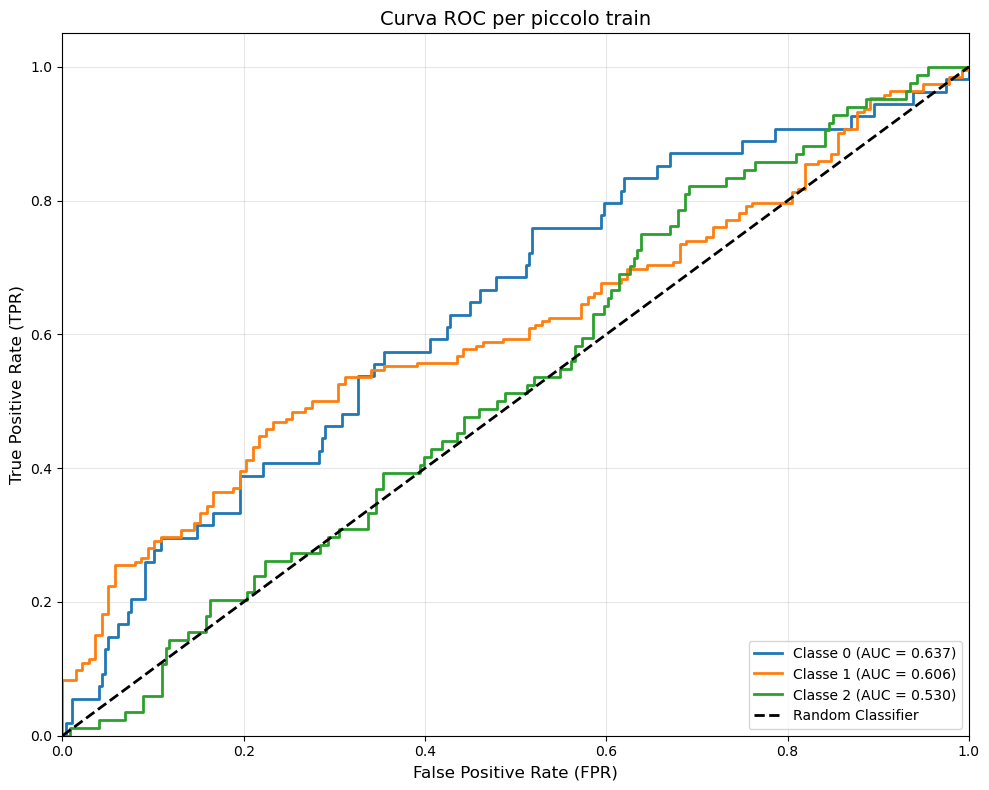

In [7]:
# Classi presenti nel test set (escludi la classe 3 "sfondo")
labels_present = np.unique(data_labels_test)  # [0, 1, 2]
print(f"Classi nel test set: {labels_present}")

probs_selected = minialexnetV2_data_test_probabilities[:, labels_present]

#Rinormalizzazione per ridistribuire la probabilià, in modo da escludere il caso Background
probs_normalized = probs_selected / probs_selected.sum(axis=1, keepdims=True)

#Verifica che sommino e diano 1
print(f"Somma probabilità (dopo normalizzazione): {probs_normalized.sum(axis=1).mean():.4f}")

#Calcola AUC con probabilità normalizzate (NON con probs_selected!)
auc_per_class = roc_auc_score(
    data_labels_test, 
    probs_normalized,  # ← Usa probs_normalized, NON probs_selected!
    multi_class='ovr', 
    average=None,
    labels=labels_present.tolist()
)

print(f"\nAUC per classe:")
for cls, auc_val in zip(labels_present, auc_per_class):
    print(f"  Classe {cls}: {auc_val:.3f}")
print(f"\nAUC macro (media): {auc_per_class.mean():.3f}")

plt.figure(figsize=(10, 8))

for i, label in enumerate(labels_present):
    # Crea bitmask per questa classe (one-vs-rest)
    y_true_binary = (data_labels_test == label).astype(int)
    # Usa la colonna corrispondente delle probabilità
    y_scores = minialexnetV2_data_test_probabilities[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'Classe {label} (AUC = {roc_auc:.3f})')

# Linea di riferimento
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Curva ROC per piccolo train', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

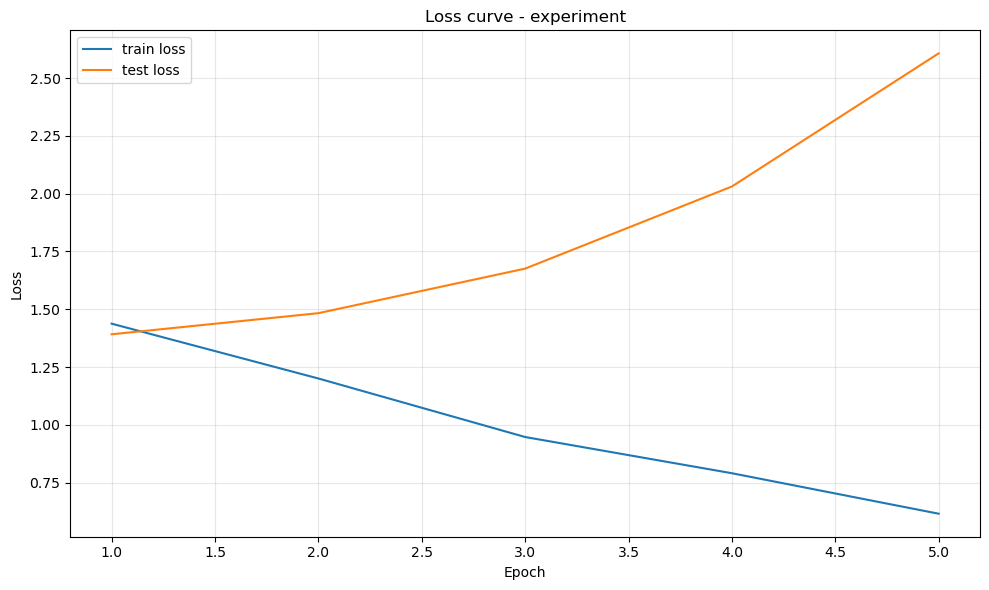

In [10]:
Function.plot_loss_from_csv(historiesDir / "minialexnetV2_dataset-5.csv", "Loss curve - experiment")